# PART A
# Inferential Statistics Project

## Objective
To apply inferential statistical techniques on a health dataset and analyze factors affecting diseases.

## Theory
### Inferential Statistics
Inferential statistics is about making predictions or inferences about a population, based on sample data. You take a small portion, analyze it, and then draw conclusions about the whole group. 

### Hypothesis Testing
1. Hypotheses

A hypothesis is a statement about a population parameter.

Null Hypothesis (H₀)
The default assumption.
Usually states that there is no effect, no difference, or no change.

Alternative hypothesis (H₁ or Ha): Assumes an effect or difference exists.

Example:

H₀: Mean Glucose Levels of Smokers and Non-Smokers are equal.
H₁: Mean Glucose Levels of Smokers and Non-Smokers are different.

### Confidence Interval
A range of values likely to contain the true population parameter.

### P-value
The p-value is the probability of obtaining the observed result, or a more extreme result, assuming that the null hypothesis (H₀) is true.
- p-value < 0.05 → Reject H₀
- p-value > 0.05 → Fail to Reject H₀

### Type I Error
Rejecting a true null hypothesis.

### Type II Error
Failing to reject a false null hypothesis.

### Brief Description of Statistical Tests

1. Z-Test (often written as Z-test, not "jet test")

Used to compare sample and population means when the sample size is large (n > 30) or population standard deviation is known.
Example: Checking whether the average height of students differs from a known population average.

2. T-Test

Used to compare means when the sample size is small (n ≤ 30) and population standard deviation is unknown.
Example: Comparing the average marks of two small groups of students.

3. Chi-Square (χ²) Test

Used to test the association between categorical variables or to check goodness of fit.
Example: Determining whether gender and product preference are related.

4. ANOVA (Analysis of Variance)

Used to compare the means of three or more groups simultaneously.
Example: Comparing the average performance of students taught by three different teaching methods.

### T-Test
Compares the means of two groups.

### Chi-Square Test
Checks the relationship between categorical variables.

### ANOVA
Compares means of more than two groups.

### Covariance
Definition:
Covariance is a statistical measure that indicates the direction of the relationship between two variables.

Interpretation:
Positive Covariance: Both variables tend to increase or decrease together.
Negative Covariance: One variable increases while the other decreases.
Zero Covariance: No linear relationship between the variables.

### Correlation
Definition:
Correlation is a statistical measure that indicates the strength and direction of the relationship between two variables.

Types:
Positive Correlation (+): Both variables move in the same direction.
Negative Correlation (−): Variables move in opposite directions.
Zero Correlation (0): No relationship between variables.


# PART B
## Import Libraries and Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


health_df = pd.read_csv("health_dataset.csv")
health_df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,a46029e8-9eb6-4792-aff6-08595e05ae87,46-60,56,68,Male,South,Non-Smoker,Daily,28.2,126.2,False,False,202.0,110.1,2026-04-17
1,7b28e913-5fd1-4fd9-8f36-ff34549548d9,36-45,38,104,Female,East,Non-Smoker,Weekly,26.1,120.9,False,True,207.2,97.5,2025-05-26
2,afef95bb-5f57-4d14-b59c-db835a064e06,60+,61,83,Female,West,Non-Smoker,Daily,23.8,135.5,False,True,204.6,116.1,2024-11-06
3,dff77c9f-0352-482a-9733-706838b70088,36-45,37,80,Female,West,Smoker,Never,29.8,145.6,False,True,206.4,79.1,2026-01-28
4,f38e379c-bae1-45df-9655-bead976b95e7,46-60,59,59,Female,South,Non-Smoker,Rarely,17.3,123.2,False,False,226.7,119.9,2025-08-17


 ## 1- Confidence Interval: Mean Blood Pressure

In [2]:
avg_bp = health_df["blood_pressure"].mean()
bp_sd = health_df["blood_pressure"].std()
sample_size = len(health_df)

z_score = stats.norm.ppf(0.975)
error = z_score * (bp_sd / np.sqrt(sample_size))

lower_limit = avg_bp - error
upper_limit = avg_bp + error

print("Mean BP:", avg_bp)
print("95% CI:", lower_limit, "to", upper_limit)

Mean BP: 128.74360000000001
95% CI: 127.64352206884342 to 129.8436779311566


## Chart: Histogram of Blood Pressure


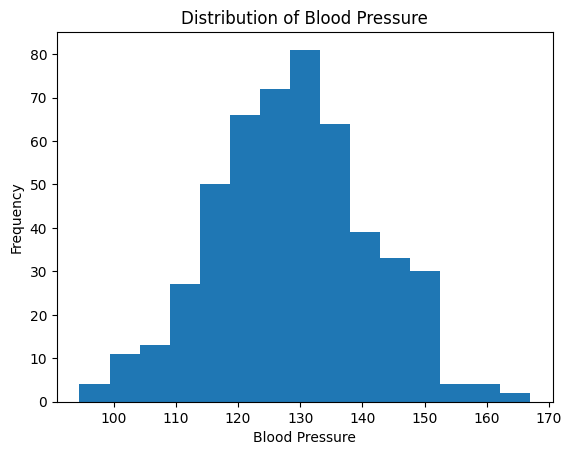

In [10]:
plt.hist(health_df["blood_pressure"], bins=15)
plt.title("Distribution of Blood Pressure")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**  
The histogram shows the distribution of blood pressure values in the dataset.

## 2- T-Test : Glucose Levels of Smokers vs Non-Smokers

In [3]:
smoker_grp = health_df.loc[
    health_df["smoking_status"] == "Smoker",
    "glucose_level"
]

nonsmoker_grp = health_df.loc[
    health_df["smoking_status"] == "Non-Smoker",
    "glucose_level"
]

test_stat, p_value = stats.ttest_ind(smoker_grp, nonsmoker_grp)

degrees_freedom = len(smoker_grp) + len(nonsmoker_grp) - 2
sig_level = 0.05

critical_t = stats.t.ppf(1 - sig_level/2, degrees_freedom)

print("Calculated t:", test_stat)
print("p-value:", p_value)
print("Critical t:", critical_t)

if p_value < sig_level:
    print("\nResult: Reject Null Hypothesis")
    print("Inference: Smoking significantly impacts glucose level.")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Inference: No significant impact of smoking on glucose level.")

Calculated t: 1.0141433408630842
p-value: 0.3111289290094023
Critical t: 1.9659272959208818

Result: Fail to Reject Null Hypothesis
Inference: No significant impact of smoking on glucose level.


## chart:Box Plot Smokers vs Non-Smokers Glucose 

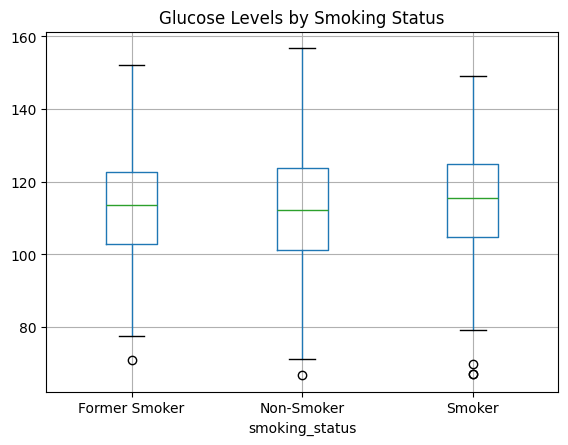

In [11]:
health_df.boxplot(column="glucose_level", by="smoking_status")

plt.title("Glucose Levels by Smoking Status")
plt.suptitle("")
plt.show()

**Interpretation:**
The box plot visually compares glucose levels between smokers and non-smokers.

## 3- Chi-Square Test : Smoking Status vs Diabetes

In [4]:
cross_tab = pd.crosstab(
    health_df["smoking_status"],
    health_df["diabetes"]
)

chi_stat, p_value, df, expected_freq = stats.chi2_contingency(cross_tab)

critical_chi = stats.chi2.ppf(0.95, df)

print("Chi-Square:", chi_stat)
print("p-value:", p_value)
print("Critical Value:", critical_chi)

if p_value < 0.05:
    print("\nResult: Reject Null Hypothesis")
    print("Inference: Smoking status and diabetes are associated.")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Inference: No statistical association detected.")

Chi-Square: 5.480253461976985
p-value: 0.06456216434778139
Critical Value: 5.991464547107979

Result: Fail to Reject Null Hypothesis
Inference: No statistical association detected.


## Chart: Stacked Bar Chart Smoking Status vs Diabetes

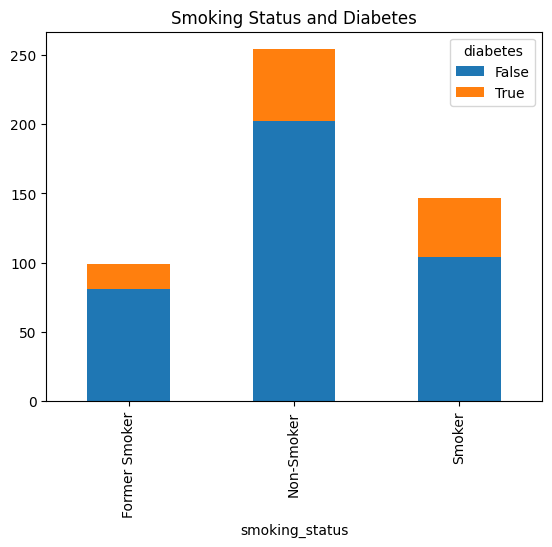

In [12]:
pd.crosstab(
    health_df["smoking_status"],
    health_df["diabetes"]
).plot(kind="bar", stacked=True)

plt.title("Smoking Status and Diabetes")
plt.show()

**Interpretation:**
The stacked bar chart shows the distribution of diabetes cases among smokers and non-smokers.

## 4- ANOVA: Blood Pressure Across Age Groups


In [6]:
bp_groups = [
    subset["blood_pressure"].to_numpy()
    for _, subset in health_df.groupby("age_group")
]

anova_f, anova_p = stats.f_oneway(*bp_groups)

group_count = len(bp_groups)
total_records = len(health_df)

df1 = group_count - 1
df2 = total_records - group_count

critical_f = stats.f.ppf(0.95, df1, df2)

print("F Statistic:", anova_f)
print("p-value:", anova_p)
print("Critical F:", critical_f)

if anova_p < 0.05:
    print("\nResult: Reject Null Hypothesis")
    print("Inference: Blood pressure varies among age categories.")
else:
    print("\nResult: Fail to Reject Null Hypothesis")
    print("Inference: No meaningful variation across age categories.")

F Statistic: 36.546319770010896
p-value: 8.820317151262241e-27
Critical F: 2.389947844458197

Result: Reject Null Hypothesis
Inference: Blood pressure varies among age categories.


## chart Box Plot : Blood Pressure Across Age Groups 

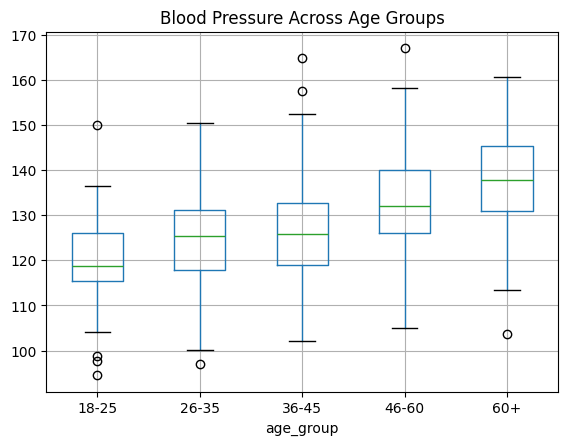

In [13]:
health_df.boxplot(column="blood_pressure", by="age_group")

plt.title("Blood Pressure Across Age Groups")
plt.suptitle("")
plt.show()

**Interpretation:**
The box plot compares blood pressure distributions across different age groups.

## 5- Covariance and Correlation

In [7]:
correlation_matrix = health_df[["age", "bmi"]].corr()
covariance_matrix = health_df[["age", "bmi"]].cov()

print("Correlation Matrix")
print(correlation_matrix)

print("\nCovariance Matrix")
print(covariance_matrix)

Correlation Matrix
          age       bmi
age  1.000000  0.064996
bmi  0.064996  1.000000

Covariance Matrix
            age        bmi
age  216.374525   3.891951
bmi    3.891951  16.571037


## chart Scatter Plot: Age vs BMI

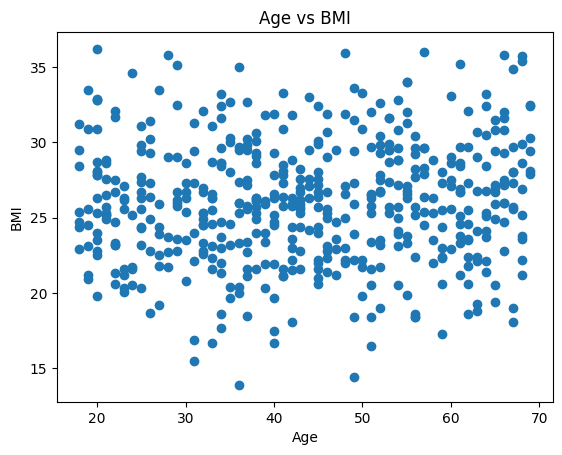

In [14]:
plt.scatter(
    health_df["age"],
    health_df["bmi"]
)

plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

**Interpretation:**
The scatter plot shows the relationship between age and BMI.

# Final Conclusion

1. A 95% Confidence Interval was calculated for Mean Blood Pressure.

2. An Independent T-Test was performed to compare Glucose Levels between Smokers and Non-Smokers.

3. Critical Values and P-Values were calculated to support statistical decision-making.

4. A Chi-Square Test was conducted to examine the relationship between Smoking Status and Diabetes.

5. ANOVA was applied to compare Mean Blood Pressure across different Age Groups.

6. Correlation and Covariance analyses were performed between Age and BMI.

7. Visualizations were created using Histogram, Box Plots, Stacked Bar Chart, and Scatter Plot to better understand the data.

8. Statistical interpretations were made using a significance level of α = 0.05.

9. Inferential statistical techniques helped identify relationships and differences among health-related variables in the dataset.